In [1]:
from autogluon.tabular import TabularPredictor, TabularDataset
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

,TimeBlock,AveragePackets,AveragePacketsperDevice,AverageConnections,AverageConnectionsperDevice,AverageThroughputperDevice,MaxThroughputperDevice,ActiveDevicesIP,ConnectedDevicesMAC,AveragePacketSize,ActiveConnections,RatioTIME_WAIT/ESTABLISHED,MaxTCPConnections,MaxUDPConnections,TimeSinceLastTCPConnection,TimeSinceLastUDPConnection,AverageTCPSessionDuration,AverageUDPSessionDuration,TimeSinceLastPacket,DeviceScreenState
1086,10,24.633333,4.926667,0.166667,0.033333,1447.026667,7235.133333,5,1,9.790438,15,0.066667,2,0,0.0,17565.0,99222.000000,0.0,15.0,0
1087,10,25.300000,5.060000,0.200000,0.040000,1504.866667,7524.333333,5,1,9.913483,16,0.125000,1,0,0.0,17580.0,93050.625000,0.0,15.0,1
1088,10,26.700000,5.340000,0.233333,0.046667,1627.466667,8137.333333,5,1,10.158968,17,0.117647,1,0,0.0,17595.0,87607.058824,0.0,15.0,0
1089,10,27.100000,5.420000,0.233333,0.046667,1652.386667,8261.933333,5,1,10.162280,17,0.117647,0,0,15.0,17610.0,87637.058824,0.0,15.0,0
1090,10,27.100000,5.420000,0.233333,0.046667,1652.386667,8261.933333,5,1,10.162280,17,0.058824,0,0,30.0,17625.0,87667.058824,0.0,30.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13045,2,28.333333,5.666667,0.366667,0.073333,1667.360000,8336.800000,5,1,9.808000,23,0.086957,2,0,0.0,105.0,275792.608696,0.0,15.0,0
13046,2,28.333333,5.666667,0.366667,0.073333,1667.360000,8336.800000,5,1,9.808000,21,0.095238,0,0,15.0,120.0,15.000000,0.0,15.0,0
13047,2,28.333333,5.666667,0.366667,0.073333,1667.360000,8336.800000,5,1,9.808000,22,0.090909,1,0,0.0,135.0,288384.545455,0.0,15.0,0
13048,2,28.333333,5.666667,0.366667,0.073333,1667.360000,8336.800000,5,1,9.808000,21,0.095238,0,0,15.0,150.0,15.000000,0.0,15.0,0


DeviceScreenState
0    7662
1    4284
Name: count, dtype: int64

DeviceScreenState
0    0.641386
1    0.358614
Name: proportion, dtype: float64

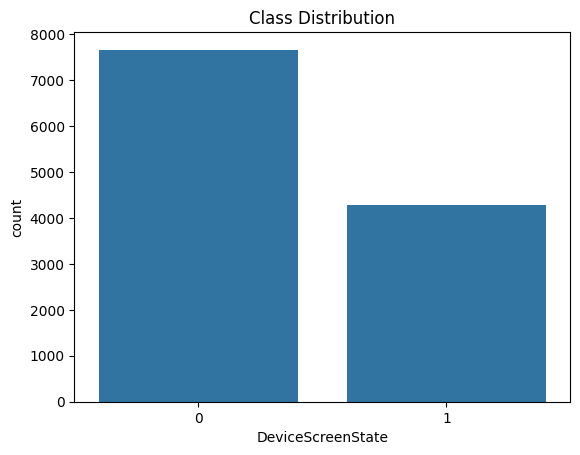

In [2]:

# Load and clean data
data = TabularDataset("busson20.csv")

data.columns = data.columns.str.replace(r"[ ()]", "", regex=True)
data = data[data["ConnectedDevicesMAC"] != 0]

# Define target column
label = "DeviceScreenState"

data = TabularDataset(data)

display(data)
# Print raw class counts
display(data[label].value_counts())

# Print class proportions
display(data[label].value_counts(normalize=True))

sns.countplot(x=label, data=data)
plt.title("Class Distribution")
plt.show()

In [3]:
# Train AutoGluon model
predictor = TabularPredictor(label=label, eval_metric="accuracy").fit(data, presets="good")

No path specified. Models will be saved in: "AutogluonModels\ag-20251210_132207"
Preset alias specified: 'good' maps to 'good_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.6
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Memory Avail:       1.46 GB / 7.62 GB (19.2%)
Disk Space Avail:   12.88 GB / 163.04 GB (7.9%)
Presets specified: ['good']
Using hyperparameters preset: hyperparameters='light'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid 

(raylet) The node with node id: 629d51b41d51c602c0f85c522236e14e43c97a19c9c6f7fd5f61faf9 and address: 127.0.0.1 and node name: 127.0.0.1 has been marked dead because the detector has missed too many heartbeats from it. This can happen when a 	(1) raylet crashes unexpectedly (OOM, etc.) 
	(2) raylet has lagging heartbeats due to slow network or busy workload.


In [4]:
# Load and clean validation set
validation = TabularDataset("busson20 copy.csv")
validation.columns = data.columns.str.replace(r"[ ()]", "", regex=True)

# Separate invalid and valid rows
invalid_rows = validation[validation["ConnectedDevicesMAC"] == 0].copy()
valid_rows = validation[validation["ConnectedDevicesMAC"] != 0].copy()

# Run leaderboard only on valid rows
leaderboard = predictor.leaderboard(valid_rows, extra_metrics=["accuracy", "recall", "precision", "f1", "roc_auc"], silent=True)
print("\nLeaderboard (sorted by score_test):")
display(leaderboard.sort_values(by="score_test", ascending=False))

# Get the highest score_test (assumed to be recall)
max_score_test = leaderboard["score_test"].max()
top_models = leaderboard[leaderboard["score_test"] == max_score_test]

# Select best model based on recall, then accuracy
best_model = None
best_accuracy = -float("inf")
best_model_results = None

if len(top_models) == 1:
    best_model = top_models.iloc[0]["model"]
    best_model_results = predictor.evaluate(valid_rows, model=best_model, silent=True)
else:
    for _, row in top_models.iterrows():
        model = row["model"]
        accuracy = row["accuracy"]
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_model_results = predictor.evaluate(valid_rows, model=best_model, silent=True)

# Show best model results
print(f"\nBest model (highest recall, then accuracy): {best_model}")
print("\nTest set performance on valid rows only:")
for metric, score in best_model_results.items():
    print(f"{metric}: {score}")

# Feature importance
importance_df = predictor.feature_importance(data, model=best_model)
importance_df_sorted = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df_sorted.index[::-1], importance_df_sorted["importance"].values[::-1], color='skyblue')
plt.xlabel("Importance")
plt.title("All Feature Importances")
plt.tight_layout()
plt.show()

# Predict on valid rows
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_valid = valid_rows["DeviceScreenState"]
y_pred_valid = predictor.predict(valid_rows, model=best_model)

# Predict on invalid rows (manually assign label 0)
invalid_rows["Predicted"] = 0
valid_rows["Predicted"] = y_pred_valid

# Confusion matrix only for valid data
cm = confusion_matrix(y_true_valid, y_pred_valid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Valid Rows Only - Best Model: {best_model}")
plt.tight_layout()
plt.show()

# OPTIONAL: Combine if you need all predictions
full_results = pd.concat([valid_rows, invalid_rows], ignore_index=True)


FileNotFoundError: [Errno 2] No such file or directory: 'busson20 copy.csv'

In [20]:
# Step 2: Identify features to remove (negative importance)
features_to_remove = importance_df[importance_df["importance"] <= 0].index.tolist()
print("\nFeatures with negative importance to remove:", features_to_remove)

# Step 3: Remove features from training and validation data
data_reduced = data.drop(columns=features_to_remove)
display(data_reduced)


Features with negative importance to remove: []


,TimeBlock,AveragePackets,AveragePacketsperDevice,AverageConnections,AverageConnectionsperDevice,AverageThroughputperDevice,MaxThroughputperDevice,ActiveDevicesIP,ConnectedDevicesMAC,AveragePacketSize,ActiveConnections,RatioTIME_WAIT/ESTABLISHED,MaxTCPConnections,MaxUDPConnections,TimeSinceLastTCPConnection,TimeSinceLastUDPConnection,AverageTCPSessionDuration,AverageUDPSessionDuration,TimeSinceLastPacket,DeviceScreenState
0,10,993.533333,993.533333,1.633333,1.633333,9.216077e+05,9.216077e+05,1,1,30.920207,49,0.224490,0,0,0.0,0.0,0.000000,0.000000,0.0,1
1,10,1211.733333,1211.733333,1.400000,1.400000,1.142716e+06,1.142716e+06,1,1,31.434756,42,0.166667,0,0,0.0,0.0,0.000000,0.000000,0.0,1
2,10,1456.333333,1456.333333,1.366667,1.366667,1.380936e+06,1.380936e+06,1,1,31.607592,41,0.146341,0,0,0.0,0.0,0.000000,0.000000,0.0,1
3,10,1410.700000,1410.700000,1.233333,1.233333,1.376384e+06,1.376384e+06,1,1,32.522481,37,0.135135,0,0,0.0,0.0,0.000000,0.000000,0.0,1
4,10,1170.566667,1170.566667,0.933333,0.933333,1.140105e+06,1.140105e+06,1,1,32.465894,28,0.178571,18,10,0.0,0.0,45.000000,55.500000,15.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85682,5,151.366667,30.273333,4.766667,0.953333,9.853307e+03,4.926653e+04,5,2,10.849270,186,0.026882,0,0,15.0,15.0,45.000000,30.000000,15.0,0
85683,5,133.033333,22.172222,4.400000,0.733333,7.032094e+03,4.219257e+04,6,3,10.571929,195,0.087179,16,4,0.0,0.0,27915.000000,55.714286,15.0,0
85684,5,128.733333,21.455556,4.266667,0.711111,6.563561e+03,3.938137e+04,6,3,10.197143,200,0.080000,9,2,0.0,0.0,75.000000,37.500000,15.0,1
85685,5,118.000000,19.666667,3.900000,0.650000,5.841833e+03,3.505100e+04,6,3,9.901412,187,0.085561,1,0,0.0,15.0,111.818182,15.000000,15.0,1


In [ ]:
# Step 4: Retrain model with reduced feature set
predictor_reduced = TabularPredictor(label=label, eval_metric="accuracy").fit(data_reduced, presets="good")

No path specified. Models will be saved in: "AutogluonModels/ag-20250723_201451"
Preset alias specified: 'good' maps to 'good_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.7
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #23-Ubuntu SMP PREEMPT_DYNAMIC Fri Jun 13 23:02:20 UTC 2025
CPU Count:          14
Memory Avail:       19.64 GB / 30.31 GB (64.8%)
Disk Space Avail:   321.43 GB / 457.28 GB (70.3%)
Presets specified: ['good']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid th


Leaderboard after removing features (sorted by score_test):


,model,score_test,accuracy,recall,precision,f1,roc_auc,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2_FULL,0.962138,0.962138,0.942501,0.943858,0.943179,0.992402,NaN,accuracy,1.531831,NaN,1811.916331,0.002631,NaN,0.739964,2,True,24
1,LightGBMLarge_BAG_L1_FULL,0.961818,0.961818,0.941303,0.944017,0.942658,0.992554,NaN,accuracy,0.551817,NaN,11.024291,0.551817,NaN,11.024291,1,True,23
2,LightGBM_BAG_L1_FULL,0.958703,0.958703,0.935074,0.940709,0.937883,0.991626,NaN,accuracy,0.820441,NaN,24.407341,0.820441,NaN,24.407341,1,True,14
3,CatBoost_BAG_L1_FULL,0.953191,0.953191,0.929564,0.930010,0.929787,0.990174,NaN,accuracy,0.017624,NaN,65.095173,0.017624,NaN,65.095173,1,True,17
4,XGBoost_BAG_L1_FULL,0.952552,0.952552,0.927887,0.929669,0.928777,0.990323,NaN,accuracy,0.137276,NaN,4.596812,0.137276,NaN,4.596812,1,True,21
5,NeuralNetTorch_BAG_L1_FULL,0.949037,0.949037,0.919981,0.926641,0.923299,0.989624,NaN,accuracy,0.056446,NaN,1708.629098,0.056446,NaN,1708.629098,1,True,22
6,LightGBMXT_BAG_L1_FULL,0.945363,0.945363,0.919023,0.917264,0.918143,0.988284,NaN,accuracy,1.058601,NaN,145.594316,1.058601,NaN,145.594316,1,True,13
7,RandomForestGini_BAG_L1,0.927710,0.927710,0.867034,0.911817,0.888862,0.981861,0.954292,accuracy,0.099887,1.531080,5.276353,0.099887,1.531080,5.276353,1,True,3
8,RandomForestGini_BAG_L1_FULL,0.927710,0.927710,0.867034,0.911817,0.888862,0.981861,NaN,accuracy,0.111009,1.531080,5.276353,0.111009,1.531080,5.276353,1,True,15
9,RandomForestEntr_BAG_L1,0.927231,0.927231,0.863440,0.913561,0.887794,0.981695,0.953622,accuracy,0.092685,1.561430,5.886993,0.092685,1.561430,5.886993,1,True,4


Computing feature importance via permutation shuffling for 19 features using 5000 rows with 5 shuffle sets...



Best model (recall): WeightedEnsemble_L2_FULL

Test set performance on valid rows only:
accuracy: 0.9621375509225977
balanced_accuracy: 0.9572302274659272
mcc: 0.9147896143686489
roc_auc: 0.9924017922584472
f1: 0.9431790937425077
precision: 0.9438579654510557
recall: 0.9425011978917106


	72.26s	= Expected runtime (14.45s per shuffle set)
	57.54s	= Actual runtime (Completed 5 of 5 shuffle sets)


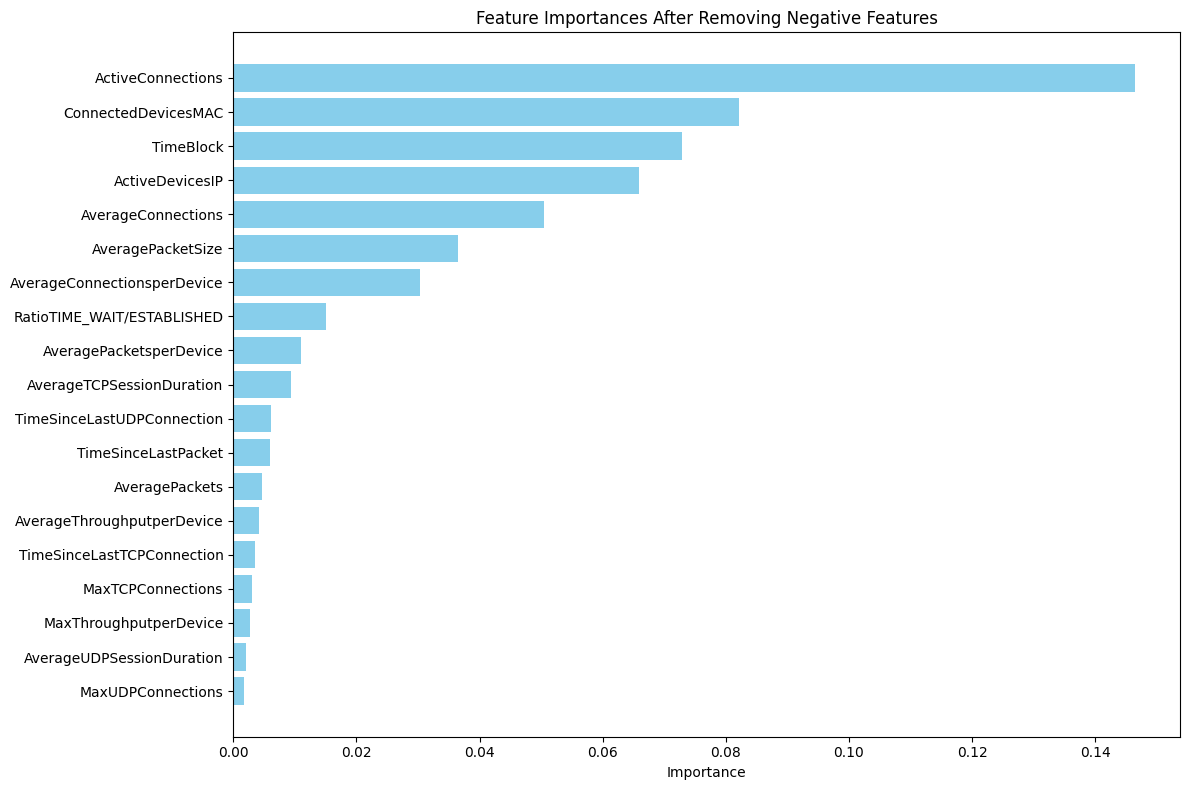

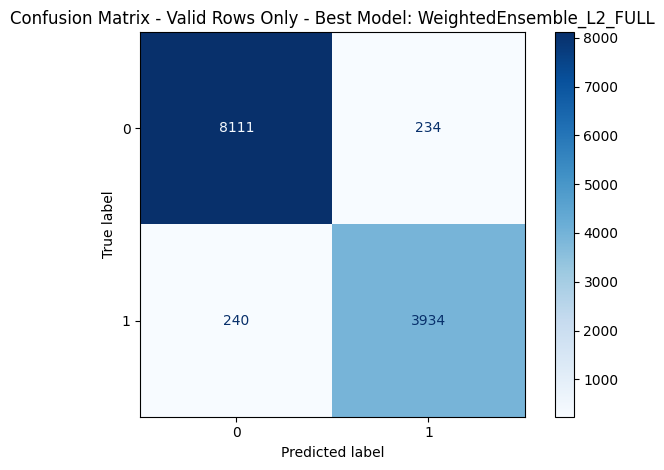

In [ ]:
# Clean validation column names
validation.columns = validation.columns.str.replace(r"[ ()]", "", regex=True)

# Separate invalid and valid validation rows
invalid_rows_reduced = validation[validation["ConnectedDevicesMAC"] == 0].copy()
valid_rows_reduced = validation[validation["ConnectedDevicesMAC"] != 0].copy()

# Step 5: Evaluate reduced model only on valid rows
leaderboard_reduced = predictor_reduced.leaderboard(valid_rows_reduced, extra_metrics=["accuracy", "recall", "precision", "f1", "roc_auc"], silent=True)
print("\nLeaderboard after removing features (sorted by score_test):")
display(leaderboard_reduced.sort_values(by="score_test", ascending=False))

# Get best model by recall (then accuracy if needed)
max_score_test = leaderboard_reduced["score_test"].max()
top_models_reduced = leaderboard_reduced[leaderboard_reduced["score_test"] == max_score_test]

best_model_reduced = None
best_accuracy = -float("inf")
best_model_results_reduced = None

if len(top_models_reduced) == 1:
    best_model_reduced = top_models_reduced.iloc[0]["model"]
    best_model_results_reduced = predictor_reduced.evaluate(valid_rows_reduced, model=best_model_reduced, silent=True)
else:
    for _, row in top_models_reduced.iterrows():
        model = row["model"]
        accuracy = row["accuracy"]

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model_reduced = model
            best_model_results_reduced = predictor_reduced.evaluate(valid_rows_reduced, model=best_model_reduced, silent=True)

print(f"\nBest model (recall): {best_model_reduced}")
print("\nTest set performance on valid rows only:")
for metric, score in best_model_results_reduced.items():
    print(f"{metric}: {score}")

# Step 6: Plot new feature importances
importance_df_reduced = predictor_reduced.feature_importance(data_reduced, model=best_model_reduced)
importance_df_sorted_reduced = importance_df_reduced.sort_values("importance", ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df_sorted_reduced.index[::-1], importance_df_sorted_reduced["importance"].values[::-1], color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importances After Removing Negative Features")
plt.tight_layout()
plt.show()

# Confusion matrix (valid rows only)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_valid_reduced = valid_rows_reduced["DeviceScreenState"]
y_pred_valid_reduced = predictor_reduced.predict(valid_rows_reduced, model=best_model_reduced)

cm = confusion_matrix(y_true_valid_reduced, y_pred_valid_reduced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Valid Rows Only - Best Model: {best_model_reduced}")
plt.tight_layout()
plt.show()

# OPTIONAL: Predict 0 for invalid rows and combine (if needed later)
invalid_rows_reduced["Predicted"] = 0
valid_rows_reduced["Predicted"] = y_pred_valid_reduced
full_results_reduced = pd.concat([valid_rows_reduced, invalid_rows_reduced], ignore_index=True)
